In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.multioutput import ClassifierChain

from catboost import CatBoostClassifier

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction.settings import from_columns

from utils import utils_ml


# Load your data
features_energies = np.array(np.load("energy_norm.pkl", allow_pickle=True))
features_intensity = np.array(np.load("intensity_norm.pkl", allow_pickle=True))
feature_names = np.load("sorted_feature_names_T11T12NoBg.npy", allow_pickle=True)[:128]

# Create DataFrame
data_df = pd.DataFrame()
data_df['id'] = np.repeat(np.arange(features_intensity.shape[0]), features_intensity.shape[1])
data_df['time'] = np.tile(np.arange(features_intensity.shape[1]), features_intensity.shape[0])
data_df['intensity'] = features_intensity.flatten()
data_df['energy'] = features_energies.flatten()

# Method 1: Using from_columns (Recommended)
# This extracts the same feature configuration from the feature names
# try:
# Create a dummy dataframe with the same structure as your original extracted features
# The feature_names should contain column names like 'intensity__mean', 'energy__variance', etc.
dummy_df = pd.DataFrame(columns=feature_names)

# Extract the feature extraction settings from these column names
kind_to_fc_parameters = from_columns(dummy_df)

# Now extract features using the same configuration
X = extract_features(data_df,
                    column_id="id",
                    column_sort="time",
                    kind_to_fc_parameters=kind_to_fc_parameters,
                    disable_progressbar=False)

# Impute any NaN values
X_imputed = impute(X)

print("Method 1 successful!")
print(f"Extracted features shape: {X_imputed.shape}")
print(f"Feature names match: {set(feature_names).issubset(set(X_imputed.columns))}")
    


Feature Extraction: 100%|██████████| 30/30 [00:27<00:00,  1.09it/s]


Method 1 successful!
Extracted features shape: (5000, 128)
Feature names match: True


In [2]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, seed=42):
        
        
        self.seed = seed
        self.esize=esize
        self.iterations=iterations
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           loss_function='MultiClass',
                           verbose=100,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e,
                           early_stopping_rounds=10)
            self.ensemble.append(model)
        
    def fit(self, X,y, eval_set = None):
        
        for m in self.ensemble:
            m.fit(X, y, use_best_model=True, early_stopping_rounds=10, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    
    def save(self, base_filepath):
        """Save the entire ensemble."""
        # Save ensemble metadata
        metadata = {
            'seed': self.seed,
            'esize': self.esize,
            'iterations': self.iterations,
        }
        joblib.dump(metadata, f"{base_filepath}_metadata.pkl")
        
        # Save each model in the ensemble
        os.makedirs(f"{base_filepath}_models", exist_ok=True)
        for idx, model in enumerate(self.ensemble):
            model.save_model(f"{base_filepath}_models/model_{idx}.cbm")
    
    def load(self, base_filepath):
        """Load the entire ensemble."""
        # Load metadata
        metadata = joblib.load(f"{base_filepath}_metadata.pkl")
        self.seed = metadata['seed']
        self.esize = metadata['esize']
        self.iterations = metadata['iterations']
       
        
        # Load each model
        self.ensemble = []
        for idx in range(self.esize):
            model = CatBoostClassifier(
                iterations=self.iterations,
                loss_function='MultiClass',
                verbose=100,
                bootstrap_type='No',
                posterior_sampling=True,
                random_seed=self.seed+idx,
                early_stopping_rounds=10
            )
            model.load_model(f"{base_filepath}_models/model_{idx}.cbm")
            self.ensemble.append(model)


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty

class EnsembleWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, esize=10, iterations=1000, seed=100):
        self.esize = esize
        self.iterations = iterations
        self.seed = seed

        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )

    def fit(self, X, y, eval_set=None):
        if eval_set is not None:
            X_val, y_val = eval_set
            eval_data = [(X_val, y_val)]
        else:
            eval_data = None
        self.ensemble.fit(X, y, eval_set=eval_data)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probs = self.ensemble.predict(X)
        mean_probs = np.mean(probs, axis=0)
        return np.argmax(mean_probs, axis=1)

    def predict_proba(self, X):
        return np.mean(self.ensemble.predict(X), axis=0)

    def predict_with_uncertainty(self, X):
        probs = self.ensemble.predict(X)
        return ensemble_uncertainties(probs), probs
    
    def save_model(self, filepath):
        """Save the ensemble wrapper model."""
        # Save wrapper metadata
        wrapper_metadata = {
            'esize': self.esize,
            'iterations': self.iterations,
            'seed': self.seed,
            'classes_': getattr(self, 'classes_', None)
        }
        joblib.dump(wrapper_metadata, f"{filepath}_wrapper.pkl")
        
        # Save the ensemble
        self.ensemble.save(filepath)
    
    def load_model(self, filepath):
        """Load the ensemble wrapper model."""
        # Load wrapper metadata
        wrapper_metadata = joblib.load(f"{filepath}_wrapper.pkl")
        self.esize = wrapper_metadata['esize']
        self.iterations = wrapper_metadata['iterations']
        self.seed = wrapper_metadata['seed']
        if wrapper_metadata['classes_'] is not None:
            self.classes_ = wrapper_metadata['classes_']
        
        # Create and load the ensemble
        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )
        self.ensemble.load(filepath)
        return self


class EvalClassifierChain(ClassifierChain):
    def fit(self, X, Y, eval_set=None, **fit_params):
        """Custom fit to support eval_set for each wrapped estimator."""
        X = np.asarray(X)
        Y = np.asarray(Y)

        self.order_ = self.order if self.order != 'random' else np.random.permutation(Y.shape[1])
        self.estimators_ = []

        for chain_idx, label_idx in enumerate(self.order_):
            y = Y[:, label_idx]
            if chain_idx > 0:
                X_extended = np.hstack((X, Y[:, self.order_[:chain_idx]]))
            else:
                X_extended = X

            estimator = clone(self.base_estimator)

            if eval_set is not None:
                X_val, Y_val = eval_set
                y_val = Y_val[:, label_idx]
                if chain_idx > 0:
                    X_val_extended = np.hstack((X_val, Y_val[:, self.order_[:chain_idx]]))
                else:
                    X_val_extended = X_val
                estimator.fit(X_extended, y, eval_set=(X_val_extended, y_val))
            else:
                estimator.fit(X_extended, y)

            self.estimators_.append(estimator)

        return self

    def save_chain(self, base_filepath):
        """Save the entire classifier chain."""
        # Save the chain structure using joblib
        chain_data = {
            'order_': self.order_,
            'order': self.order,
            'base_estimator': self.base_estimator
        }
        joblib.dump(chain_data, f"{base_filepath}_chain.pkl")
        
        # Save each individual estimator
        os.makedirs(f"{base_filepath}_chain_models", exist_ok=True)
        for idx, estimator in enumerate(self.estimators_):
            if hasattr(estimator, 'save_model'):
                estimator.save_model(f"{base_filepath}_chain_models/estimator_{idx}")
            else:
                joblib.dump(estimator, f"{base_filepath}_chain_models/estimator_{idx}.pkl")

    def load_chain(self, base_filepath, classes=None):
        """Load the entire classifier chain."""
        # Load chain structure
        chain_data = joblib.load(f"{base_filepath}_chain.pkl")
        self.order_ = chain_data['order_']
        self.order = chain_data['order']
        self.base_estimator = chain_data['base_estimator']
        
        # Load individual estimators
        self.estimators_ = []
        for idx in range(len(self.order_)):
            estimator = clone(self.base_estimator)
            
            if hasattr(estimator, 'load_model'):
                estimator.load_model(f"{base_filepath}_chain_models/estimator_{idx}")
                # Set classes if provided
                if classes is not None:
                    estimator.classes_ = classes
            else:
                pkl_path = f"{base_filepath}_chain_models/estimator_{idx}.pkl"
                if os.path.exists(pkl_path):
                    estimator = joblib.load(pkl_path)
            
            self.estimators_.append(estimator)
        
        return self

In [3]:
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, 10000) 
    for i in np.arange(num_files)
]).flatten()#[::100]

def convert_labels(old_labels, class_to_poles):
    """
    Convert class labels to pole representation.
    
    Parameters:
        old_labels (np.ndarray): Array of class labels.
        class_to_poles (dict): Mapping from class labels to pole representations.
        
    Returns:
        np.ndarray: A 2D array with pole representations.
    """
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

y_arr_regression = convert_labels(y_arr_classification, class_to_poles) * 1.0



Loading labels...


In [4]:
i = 0
base_model = EnsembleWrapper(esize=5, iterations=1000, seed=42)

unique_classes = np.array([0, 1, 2,])
new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
new_chain.load_chain(f"models/catboost_model_c3ru_fold{i}", classes=np.unique(y_arr_regression))

# Verify loaded model works
y_pred = new_chain.predict(X_imputed)
y_pred
# acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but EvalClassifierChain was fitted without feature names
  warnings.warn(


array([[1., 2., 1.],
       [2., 2., 1.],
       [1., 2., 1.],
       ...,
       [1., 2., 1.],
       [1., 2., 1.],
       [1., 2., 1.]])

In [5]:
# Get pole1 predictions + uncertainty
pole1_uncertainty, pole1_probs = new_chain.estimators_[0].predict_with_uncertainty(X_imputed)
pole1_preds = np.argmax(np.mean(pole1_probs, axis=0), axis=1)
X2 = np.concatenate([X_imputed, pole1_preds[:, None]], axis=1)

# Get pole2 predictions + uncertainty
pole2_uncertainty, pole2_probs = new_chain.estimators_[1].predict_with_uncertainty(X2)
pole2_preds = np.argmax(np.mean(pole2_probs, axis=0), axis=1)
X3 = np.concatenate([X2, pole2_preds[:, None]], axis=1)

# Get pole3 predictions + uncertainty
pole3_uncertainty, pole3_probs = new_chain.estimators_[2].predict_with_uncertainty(X3)


In [6]:
predictions = np.stack([np.argmax(np.mean(pole1_probs, axis=0), axis=1),
np.argmax(np.mean(pole2_probs, axis=0), axis=1),
np.argmax(np.mean(pole3_probs, axis=0), axis=1),],axis=1)

predictions_proba = np.stack([np.mean(pole1_probs, axis=0),
np.mean(pole2_probs, axis=0),
np.mean(pole3_probs, axis=0)],axis=1)

In [7]:
expected_entropy = np.stack([pole1_uncertainty["expected_entropy"],
                             pole2_uncertainty["expected_entropy"],
                             pole3_uncertainty["expected_entropy"]],axis=-1)

mutual_information = np.stack([pole1_uncertainty["mutual_information"],
                             pole2_uncertainty["mutual_information"],
                             pole3_uncertainty["mutual_information"]],axis=-1)
confidence = np.stack([pole1_uncertainty["confidence"],
                             pole2_uncertainty["confidence"],
                             pole3_uncertainty["confidence"]],axis=-1)


[2.57845772e-04 9.84165900e-01 1.47995462e-02 7.20292814e-04
 5.64153725e-05]
[1.77441972e-03 5.75670693e-02 9.26143515e-01 1.43914516e-02
 1.23543996e-04]
[1.71695957e-02 9.78283692e-01 4.52736958e-03 5.83859169e-06
 1.35041251e-05]


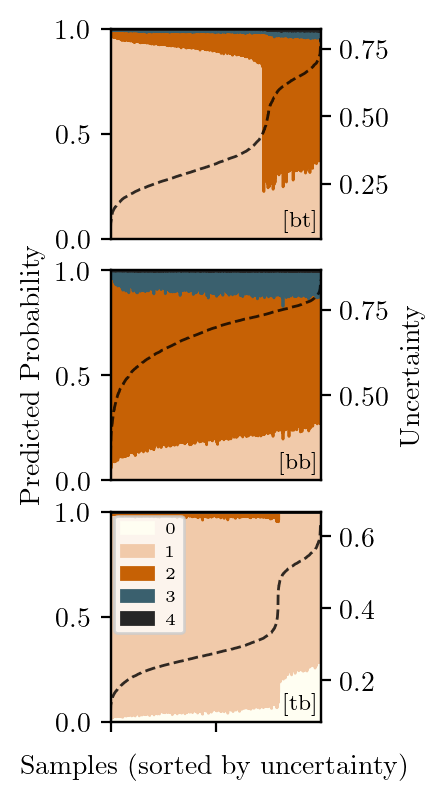

In [8]:


plt.rcParams.update({
    'font.size': 7,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 6,
    'figure.titlesize': 10
})

def plot_class_probabilities_with_uncertainty(class_probabilities, uncertainties, 
                                              targets=["BT", "BB", "TB"]):
    """
    Plot class probability distributions with uncertainty for single-column layout.
    Each subplot is square in figure layout (not in data coordinates).
    """
    n_classes = class_probabilities.shape[2]
    n_targets = len(targets)

    # Set width and height to make square plots stacked vertically
    square_size = 1.5  # inches per subplot
    fig, axes = plt.subplots(n_targets, 1, figsize=(square_size, n_targets * square_size),
                             sharex=True, gridspec_kw={'hspace': 0.15})

    # Ensure axes is always a list
    if n_targets == 1:
        axes = [axes]

    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
    colors = ["#fffef2","#f1caaa","#c66105","#3a606e","#262626"]
    

    for i, (target, ax) in enumerate(zip(targets, axes)):
        sort_idx = np.argsort(uncertainties[:, i])
        sorted_probs = class_probabilities[sort_idx, i, :]
        sorted_uncertainties = uncertainties[sort_idx, i]

        print(sorted_probs[0])

        # Stacked filled areas instead of bars
        x = np.arange(len(sort_idx))
        bottom = np.zeros(len(sort_idx))
        for class_idx in range(n_classes):
            top = bottom + sorted_probs[:, class_idx]
            ax.fill_between(x, bottom, top,
                            color=colors[class_idx], alpha=1.0,
                            label=f'{class_idx}' if i == 2 else "")
            bottom = top

        ax.set_xlim(0, len(x) - 1)
        ax.set_ylim(0, 1)

        ax2 = ax.twinx()
        ax2.plot(x, sorted_uncertainties, color='black', linewidth=1.0,
                 alpha=0.8, linestyle='--')
        if i == 1:
            ax2.set_ylabel('Uncertainty')
        ax2.tick_params(axis='y')

        ax.set_box_aspect(1)
        # ax.grid(True, linestyle='--', alpha=0.7)
        ax.text(1.0-0.005, 0.03, f'[{target.lower()}]', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8,
                bbox=dict(facecolor='none', edgecolor='none', alpha=0.7))

        if i == 1:
            ax.set_ylabel('Predicted Probability')
        if i == n_targets - 1:
            ax.set_xlabel('Samples (sorted by uncertainty)')
        if i != 2 :
            ax.set_xticklabels([])
            ax.tick_params(axis='x', which='both', length=0)
        if i == 2:
            ax.legend(bbox_to_anchor=(-0.02, 1.02), loc='upper left', fontsize="small")


    return fig

predictions_proba = np.stack([np.mean(pole1_probs, axis=(0)),
    np.mean(pole2_probs, axis=(0)),
    np.mean(pole3_probs, axis=(0))],axis=1)
 
fig = plot_class_probabilities_with_uncertainty(predictions_proba[::1], expected_entropy[::1], 
                                              targets=["BT", "BB", "TB"])


plt.savefig("class_probabilities_uncertainty_norm.pdf", dpi=300, bbox_inches='tight', pad_inches=0.1)

In [9]:
 9.84165900e-01, 9.26143515e-01, 9.78283692e-01 

(0.9841659, 0.926143515, 0.978283692)